# 🤖 Tự Động Tối Ưu Alpha Bằng Thuật Toán Học Máy (Gradient Descent)

Notebook này thiết lập một hàm **Loss Differentiable (Vi phân được)** dựa trên cấu trúc đồ thị (Entropy đa dạng, Bất đối xứng không gian do gió, và hình phạt đứt gãy mạng). 
Thay vì đoán mò hoặc quét thủ công (grid search), chúng ta sử dụng `PyTorch AutoGrad` (Gradient Descent) để tự động di chuyển **thông số Alpha** $\alpha$ trốn khỏi các bẫy cực đoan và hội tụ về điểm rơi tối ưu nhất.

**Thuật toán tối ưu (Optimizer):** Nhấp nhô Adam (AdamW).
**Hàm Mục Tiêu (Objective/Loss):** $\mathcal{L} = - w_1 \cdot \text{Entropy} - w_2 \cdot \text{Asymmetry} + w_3 \cdot \text{Sparsity\_Penalty}$

In [56]:
# ── 1. Nạp Thư Viện ───────────────────────────────────────────────────────────
import os, sys
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

NOTEBOOK_DIR = os.path.abspath('')
ROOT_DIR     = os.path.dirname(NOTEBOOK_DIR)
S09_DIR      = os.path.join(ROOT_DIR, 'models', 'S09_XLinear_Clean')
sys.path.insert(0, S09_DIR)

from graph import get_base_matrices

DATA_DIR    = os.path.join(ROOT_DIR, 'data')
INFO_PATH   = os.path.join(DATA_DIR, 'info.csv')
WEATHER_DIR = os.path.join(DATA_DIR, 'raw', 'weather')

print(' Các đường dẫn đã được chuẩn bị sẵn sàng.')

 Các đường dẫn đã được chuẩn bị sẵn sàng.


In [57]:
# ── 2. Bộ Dữ Liệu Trạm Không Khí Đã Phân Cụm ──────────────────────────────────
cluster_north = [1, 2, 3, 4, 5, 6, 16, 17, 27, 28]
cluster_south = [7, 18, 24, 30, 31, 32]
SELECTED      = sorted(cluster_north + cluster_south)
N = len(SELECTED)

print(f"Tổng số trạm tham gia quá trình tối ưu: {N}")

Tổng số trạm tham gia quá trình tối ưu: 16


In [58]:
# ── 3. Trích Xuất Ma Trận Nền (H & W) Từ Dữ Liệu Thực ─────────────────────────
df_info = pd.read_csv(INFO_PATH)
df_sel  = df_info[df_info['station'].isin(SELECTED)].copy()

dist_km, bearings = get_base_matrices(INFO_PATH, SELECTED)

# Tải dữ liệu hệ gió địa phương (Raw Weather Data)
wind_dir = np.zeros(N)
for k, sid in enumerate(SELECTED):
    fpath = os.path.join(WEATHER_DIR, f'weather_{sid}.csv')
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        wd_rad = np.deg2rad(df['wind_direction_10m (°)'])
        avg_sin, avg_cos = np.sin(wd_rad).mean(), np.cos(wd_rad).mean()
        wind_dir[k] = (np.arctan2(avg_sin, avg_cos) + 2*np.pi) % (2*np.pi)
    else:
        print(f' Thiếu dữ liệu gió trạm {sid}, gán mặc định (0)')

# Xây dựng Ma trận Tĩnh H (Khoảng Cách Mềm)
# => Sử dụng std() tĩnh học để đồng nhất cơ sở vật lý với bản Manual
sigma2 = dist_km[dist_km > 0].std() ** 2
H = np.exp(-(dist_km**2) / sigma2)
np.fill_diagonal(H, 1.0)

# Xây dựng Ma trận Tĩnh W (Sự Thuận Gió)
# => Sử dụng chuẩn Cosine góc lệch để mượt mà (0->1) đồng nhất hoàn toàn
W = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i == j: 
            W[i,j] = 1.0; continue
        angle_diff = bearings[i, j] - wind_dir[i]
        W[i, j] = (np.cos(angle_diff) + 1.0) / 2.0

# Cố định dữ liệu nền thành Gradient PyTorch Tensors
H_t = torch.tensor(H, dtype=torch.float32)
W_t = torch.tensor(W, dtype=torch.float32)
print("Tensor H và W đã sẵn sàng chuẩn hoá đồng bộ")

Tensor H và W đã sẵn sàng chuẩn hoá đồng bộ


In [ ]:
# ── 4. Thuật Toán Định Hướng Alpha Optimizer Bằng Neural Modules ────────────
class AlphaOptimizer(nn.Module):
    def __init__(self, init_alpha=0.1):
        super().__init__()
        # Khởi tạo siêu tham số trong không gian logit. Sigmoid giữ alpha ∈ [0, 1]
        init_l = np.log(init_alpha/(1-init_alpha)) if init_alpha not in [0.0, 1.0] else -3.0
        self.logit = nn.Parameter(torch.tensor(init_l, dtype=torch.float32))
        
    def forward(self, H, W):
        alpha = torch.sigmoid(self.logit)
        # Công thức cốt lõi
        adj = H * ((1.0 - alpha) + alpha * W)
        return adj, alpha

def structural_loss(adj, alpha):
    off_diag = adj[~torch.eye(adj.shape[0], dtype=torch.bool)]
    
    # 1. Entropy (Đa dạng hoá kết nối không gian)
    p = off_diag / (off_diag.sum() + 1e-8)
    entropy = -torch.sum(p * torch.log(p + 1e-8))
    
    # 2. Asymmetry (Tính Véc-tơ nhân quả của đồ thị do lực Gió)
    asymmetry = torch.mean(torch.abs(adj - adj.T))
    
    # 3. Sparsity Penalty (Ngăn cản Graph bị mất cành băm nát vì góc gió quá khắc nghiệt)
    # Phạt tất cả những cạnh có trọng số bị rớt xuống dưới 0.3
    sparsity_penalty = torch.mean(torch.relu(0.5 - off_diag))
    
    # Đặt Trọng số phạt (Loss weights dựa trên phân tích hình ảnh trước)
    w_entropy = -1.0   # Muốn Maximize entropy nên đặt dấu âm
    w_asymm   = -1.0   # Muốn Graph siêu hướng nghịch nên ép màng âm mạng
    w_sparse  = 6.0    # Phạt rất nặng việc chặt đứt cành
    
    loss = (w_entropy * entropy) + (w_asymm * asymmetry) + (w_sparse * sparsity_penalty)
    
    return loss, entropy, asymmetry

In [60]:
# ── 5. Vòng Lặp Huấn Luyện (Gradient Descent Backward Pass) ─────────────────
model = AlphaOptimizer(init_alpha=0.1)   # Xuất phát từ môi trường gió nhẹ
optimizer = optim.Adam(model.parameters(), lr=0.03)

epochs = 300
history = {'loss': [], 'alpha': [], 'entropy': [], 'asymmetry': []}

for epoch in range(epochs):
    optimizer.zero_grad()
    
    adj, alpha = model(H_t, W_t)
    loss, entropy, asymm = structural_loss(adj, alpha)
    
    loss.backward()      # Sinh Gradient Backprop
    optimizer.step()     # Di chuyển tham số alpha
    
    history['loss'].append(loss.item())
    history['alpha'].append(alpha.item())
    history['entropy'].append(entropy.item())
    history['asymmetry'].append(asymm.item())
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss.item():.4f} | Alpha: {alpha.item():.4f} | Sys Entropy: {entropy.item():.4f}")

optimal_alpha = history['alpha'][-1]
print(f"\n QUÁ TRÌNH AUTO-OPTIMIZE KẾT THÚC!")
print(f"[KẾT QUẢ] Alpha Cân Bằng Cấu Trúc Khuyên Dùng: {optimal_alpha:.4f}")

Epoch  50/300 | Loss: -3.4516 | Alpha: 0.3521 | Sys Entropy: 4.8289
Epoch 100/300 | Loss: -3.4683 | Alpha: 0.4891 | Sys Entropy: 4.8118
Epoch 150/300 | Loss: -3.4685 | Alpha: 0.4859 | Sys Entropy: 4.8123
Epoch 200/300 | Loss: -3.4685 | Alpha: 0.4855 | Sys Entropy: 4.8123
Epoch 250/300 | Loss: -3.4685 | Alpha: 0.4856 | Sys Entropy: 4.8123
Epoch 300/300 | Loss: -3.4685 | Alpha: 0.4858 | Sys Entropy: 4.8123

 QUÁ TRÌNH AUTO-OPTIMIZE KẾT THÚC!
[KẾT QUẢ] Alpha Cân Bằng Cấu Trúc Khuyên Dùng: 0.4858


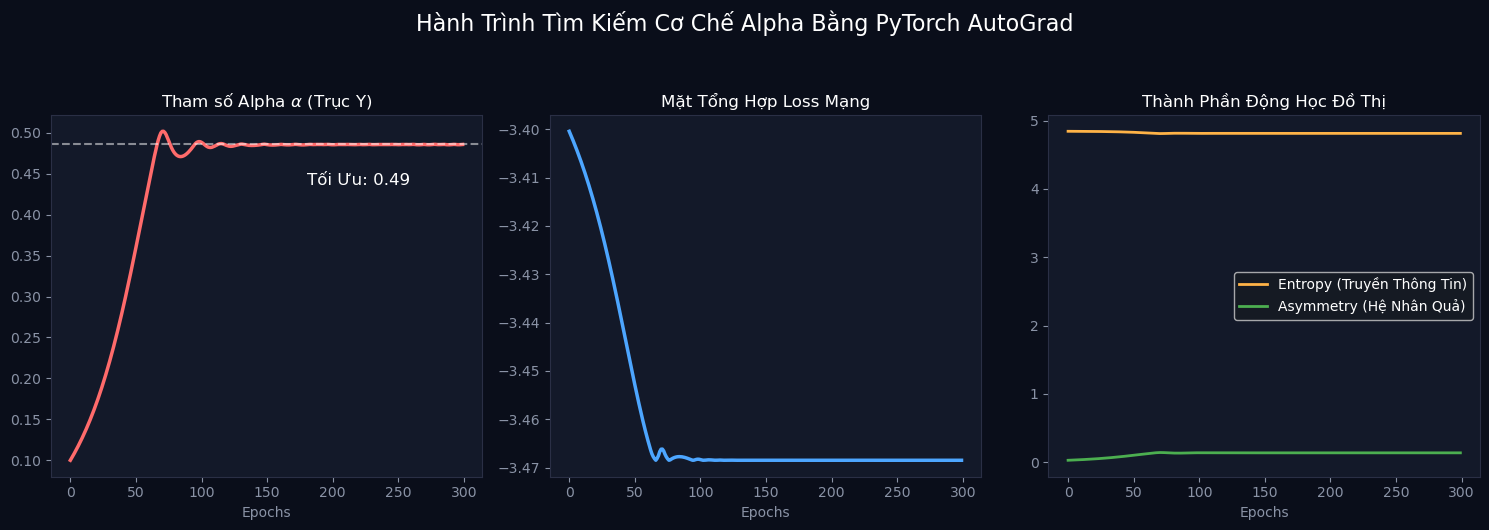

In [61]:
# ── 6. Trình Bày Convergence Curves (Sự Hội Tụ Của Giải Thuật) ──────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0A0E1A', subplot_kw={'facecolor':'#131929'})
fig.suptitle('Hành Trình Tìm Kiếm Cơ Chế Alpha Bằng PyTorch AutoGrad', color='white', fontsize=16, y=1.05)

ax = axes[0]
ax.plot(history['alpha'], color='#FF6B6B', lw=2.5)
ax.set_title('Tham số Alpha $\\alpha$ (Trục Y)', color='white')
ax.axhline(optimal_alpha, color='white', ls='--', alpha=0.5)
ax.text(epochs*0.6, optimal_alpha-0.05, f"Tối Ưu: {optimal_alpha:.2f}", color='white', fontsize=12)

ax = axes[1]
ax.plot(history['loss'], color='#4DA6FF', lw=2.5)
ax.set_title('Mặt Tổng Hợp Loss Mạng', color='white')

ax = axes[2]
ax.plot(history['entropy'], color='#FFB347', lw=2, label='Entropy (Truyền Thông Tin)')
ax.plot(history['asymmetry'], color='#4CAF50', lw=2, label='Asymmetry (Hệ Nhân Quả)')
ax.set_title('Thành Phần Động Học Đồ Thị', color='white')
ax.legend(facecolor='#161B22', labelcolor='white')

for ax in axes:
    ax.set_xlabel('Epochs', color='#8A93A6')
    ax.tick_params(colors='#8A93A6')
    for sp in ax.spines.values(): sp.set_edgecolor('#2A2F45')

plt.tight_layout()
plt.show()

In [62]:
# ── 7. Bảng Chỉ Số Định Lượng Của Alpha Tối Ưu Mới Tìm Được ─────────────────
import pandas as pd
from IPython.display import display, HTML

# Tính toán lại cấu trúc ma trận với optimal_alpha
adj_opt = H_t * ((1.0 - optimal_alpha) + optimal_alpha * W_t)
off_diag_opt = adj_opt[~torch.eye(N, dtype=torch.bool)]

mean_opt = off_diag_opt.mean().item()
std_opt  = off_diag_opt.std().item()

p_opt = off_diag_opt / (off_diag_opt.sum() + 1e-12)
entropy_opt = -torch.sum(p_opt * torch.log(p_opt + 1e-12)).item()

asymmetry_opt = torch.mean(torch.abs(adj_opt - adj_opt.T)).item()

df_res = pd.DataFrame([{
    'α': optimal_alpha,
    'mean': mean_opt,
    'std': std_opt,
    'entropy': entropy_opt,
    'asymm.': asymmetry_opt
}])

print('\nKẾT QUẢ ĐỊNH LƯỢNG CHO ALPHA TỐI ƯU CỦA HỆ THỐNG:')
display(df_res.style.format(precision=4).set_properties(**{
    'background-color': '#0D1428', 
    'color': 'white', 
    'border-color': '#30363D', 
    'text-align': 'center'
}))


KẾT QUẢ ĐỊNH LƯỢNG CHO ALPHA TỐI ƯU CỦA HỆ THỐNG:


,α,mean,std,entropy,asymm.
0,0.4858,0.3713,0.3838,4.8123,0.1371
